# Indian Bank Customer Analysis


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("indian_bank_customers_10000_enhanced.csv")
print("Total rows before cleaning:", len(df))
df.isnull().sum()

Total rows before cleaning: 10200


Client ID                     0
Name                          0
Age                           0
State                         0
City                          0
Location ID                   0
Joined Bank                   0
Banking Contact               0
Nationality                   0
Occupation                  509
Fee Structure                 0
Loyalty Classification        0
Estimated Income            509
Superannuation Savings        0
Amount of Credit Cards        0
Credit Card Balance         514
Bank Loans                    0
Bank Deposits                 0
Checking Accounts             0
Saving Accounts               0
Foreign Currency Account      0
Business Lending            507
Properties Owned              0
Risk Weighting                0
BRId                          0
GenderId                      0
IAId                          0
dtype: int64

## 1 & 11. Data Cleaning + Data Quality Monitoring

In [ ]:
# remove duplicate rows
df = df.drop_duplicates()

# remove invalid age
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]

# fill missing occupation
df["Occupation"] = df["Occupation"].fillna("Unknown")

# fill missing income with median
df["Estimated Income"] = df["Estimated Income"].fillna(df["Estimated Income"].median())

# fill missing credit card balance with median
df["Credit Card Balance"] = df["Credit Card Balance"].fillna(df["Credit Card Balance"].median())

# fill missing business lending with 0
df["Business Lending"] = df["Business Lending"].fillna(0)

print("Total rows after cleaning:", len(df))
df.to_csv("clean_bank_customers.csv", index=False)

Total rows after cleaning: 10000


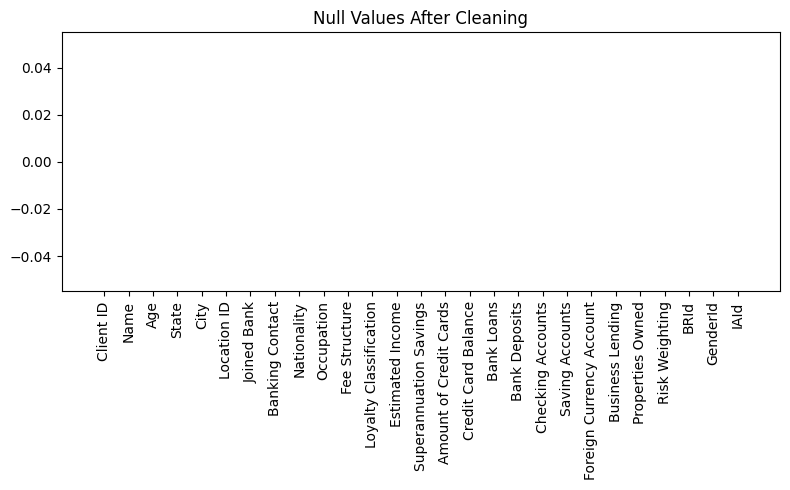

In [ ]:
null_counts = df.isnull().sum()
plt.figure(figsize=(8, 5))
plt.bar(null_counts.index, null_counts.values, color="steelblue")
plt.xticks(rotation=90)
plt.title("Null Values After Cleaning")
plt.tight_layout()
plt.savefig("chart1_null_values.png")
plt.show()

## 2. Customer Segmentation

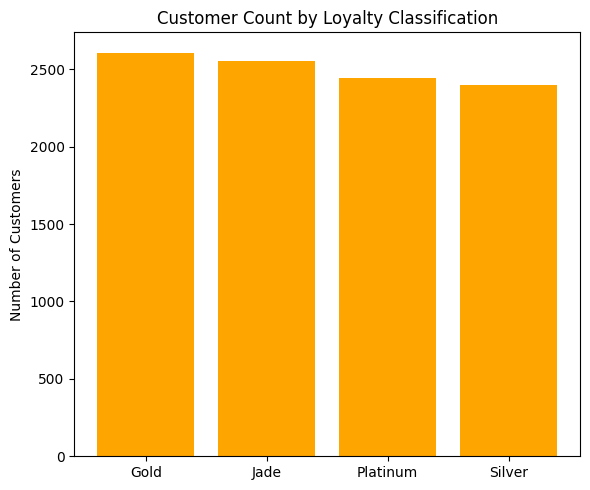

In [ ]:
# Gender mapping (1=Male, 2=Female)
df["Gender"] = df["GenderId"].map({1: "Male", 2: "Female"})

loyalty_count = df["Loyalty Classification"].value_counts()
plt.figure(figsize=(6, 5))
plt.bar(loyalty_count.index, loyalty_count.values, color="orange")
plt.title("Customer Count by Loyalty Classification")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("chart2_loyalty_count.png")
plt.show()

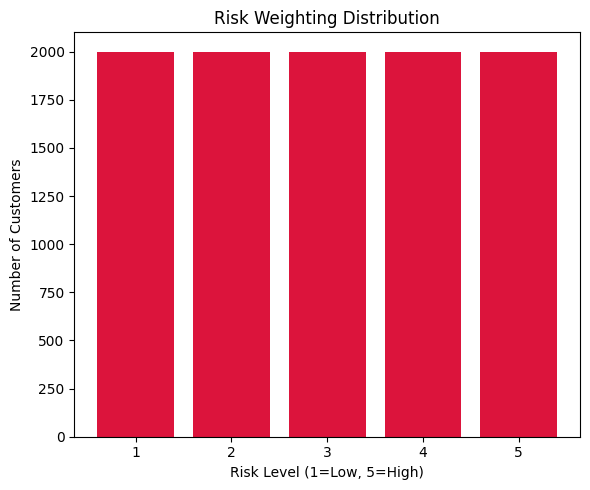

In [ ]:
risk_count = df["Risk Weighting"].value_counts().sort_index()
plt.figure(figsize=(6, 5))
plt.bar(risk_count.index.astype(str), risk_count.values, color="crimson")
plt.title("Risk Weighting Distribution")
plt.xlabel("Risk Level (1=Low, 5=High)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("chart3_risk_distribution.png")
plt.show()

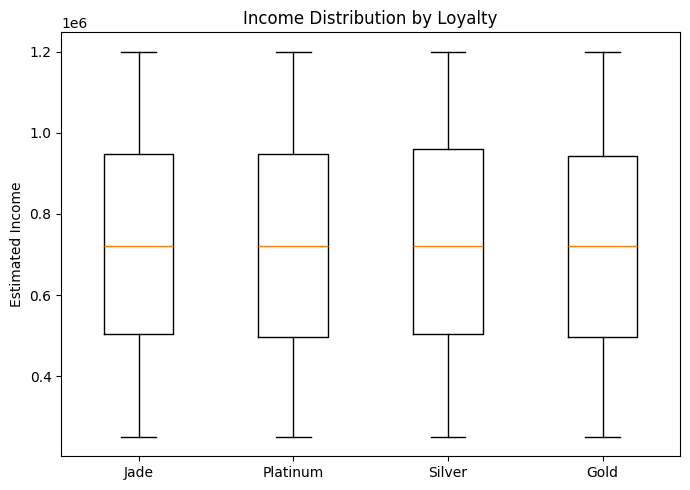

In [ ]:
plt.figure(figsize=(7, 5))
groups = [df[df["Loyalty Classification"] == cat]["Estimated Income"] for cat in df["Loyalty Classification"].unique()]
plt.boxplot(groups, tick_labels=df["Loyalty Classification"].unique(), showfliers=False)
plt.title("Income Distribution by Loyalty")
plt.ylabel("Estimated Income")
plt.tight_layout()
plt.savefig("chart4_income_boxplot.png")
plt.show()

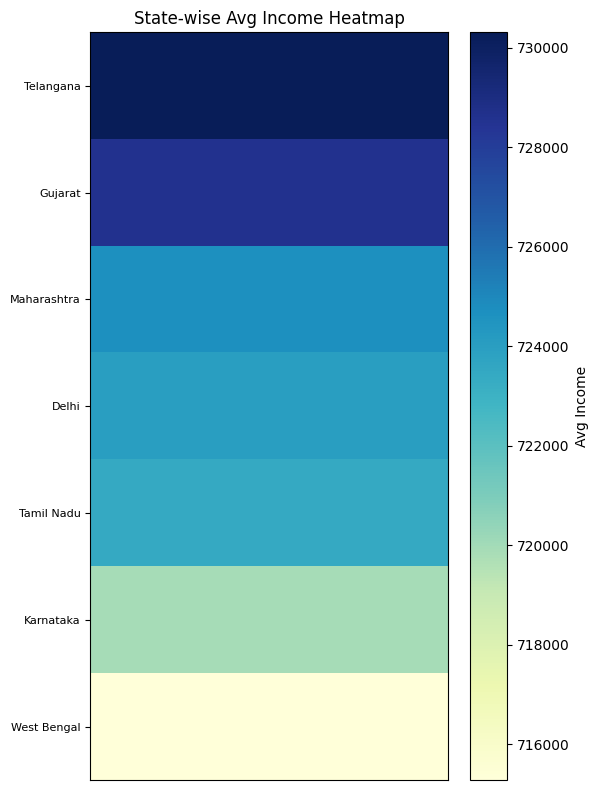

In [ ]:
state_income = df.groupby("State")["Estimated Income"].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 8))
plt.imshow(state_income.values.reshape(-1, 1), cmap="YlGnBu", aspect="auto")
plt.yticks(range(len(state_income)), state_income.index, fontsize=8)
plt.xticks([])
plt.colorbar(label="Avg Income")
plt.title("State-wise Avg Income Heatmap")
plt.tight_layout()
plt.savefig("chart5_state_income_heatmap.png")
plt.show()

In [ ]:
income_75 = df["Estimated Income"].quantile(0.75)
income_25 = df["Estimated Income"].quantile(0.25)

df["High Value"] = (df["Estimated Income"] >= income_75) & (df["Risk Weighting"] <= 2)
df["Risky"] = df["Risk Weighting"] >= 4
df["Low Profit"] = (df["Estimated Income"] <= income_25) & (df["Bank Deposits"] < df["Bank Deposits"].median())

print("High value customers:", df["High Value"].sum())
print("Risky customers:", df["Risky"].sum())
print("Low profit customers:", df["Low Profit"].sum())

High value customers: 998
Risky customers: 4000
Low profit customers: 1260


## 3. Credit Risk Analysis

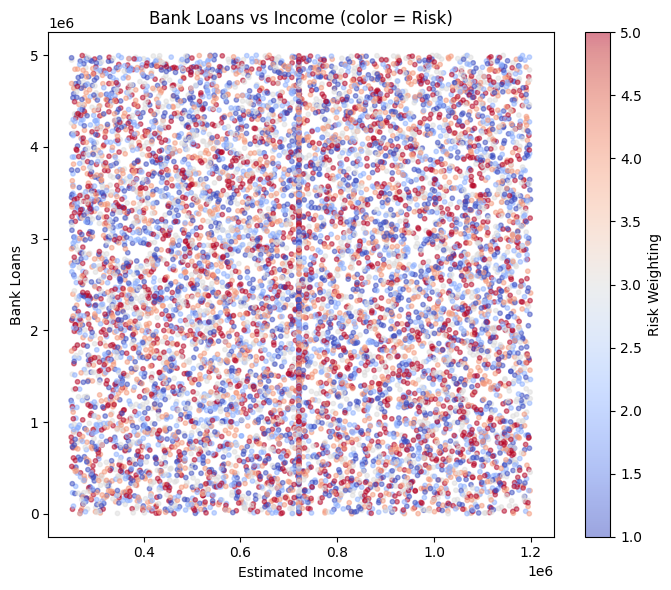

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(df["Estimated Income"], df["Bank Loans"], c=df["Risk Weighting"], cmap="coolwarm", alpha=0.5, s=10)
plt.xlabel("Estimated Income")
plt.ylabel("Bank Loans")
plt.title("Bank Loans vs Income (color = Risk)")
plt.colorbar(label="Risk Weighting")
plt.tight_layout()
plt.savefig("chart6_loans_vs_income.png")
plt.show()

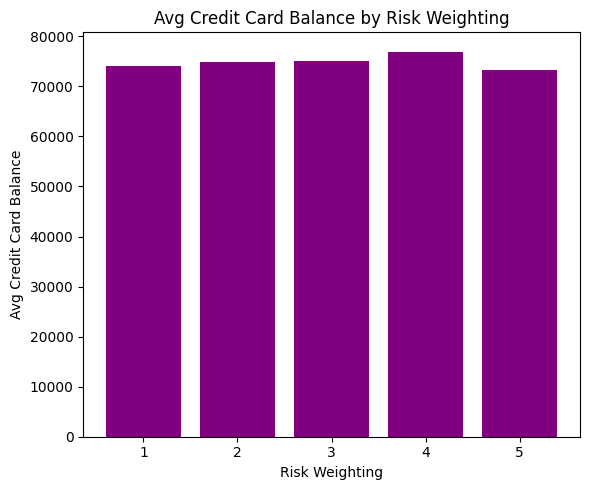

In [ ]:
cc_by_risk = df.groupby("Risk Weighting")["Credit Card Balance"].mean()
plt.figure(figsize=(6, 5))
plt.bar(cc_by_risk.index.astype(str), cc_by_risk.values, color="purple")
plt.title("Avg Credit Card Balance by Risk Weighting")
plt.xlabel("Risk Weighting")
plt.ylabel("Avg Credit Card Balance")
plt.tight_layout()
plt.savefig("chart7_ccbalance_by_risk.png")
plt.show()

In [ ]:
loan_75 = df["Bank Loans"].quantile(0.75)
df["Red Flag"] = ((df["Bank Loans"] >= loan_75) & (df["Estimated Income"] <= income_25)) | \
                  ((df["Properties Owned"] >= 2) & (df["Bank Loans"] >= loan_75))

print("Red flag customers:", df["Red Flag"].sum())

Red flag customers: 1871


## 4 & 5. State/City Performance and Revenue

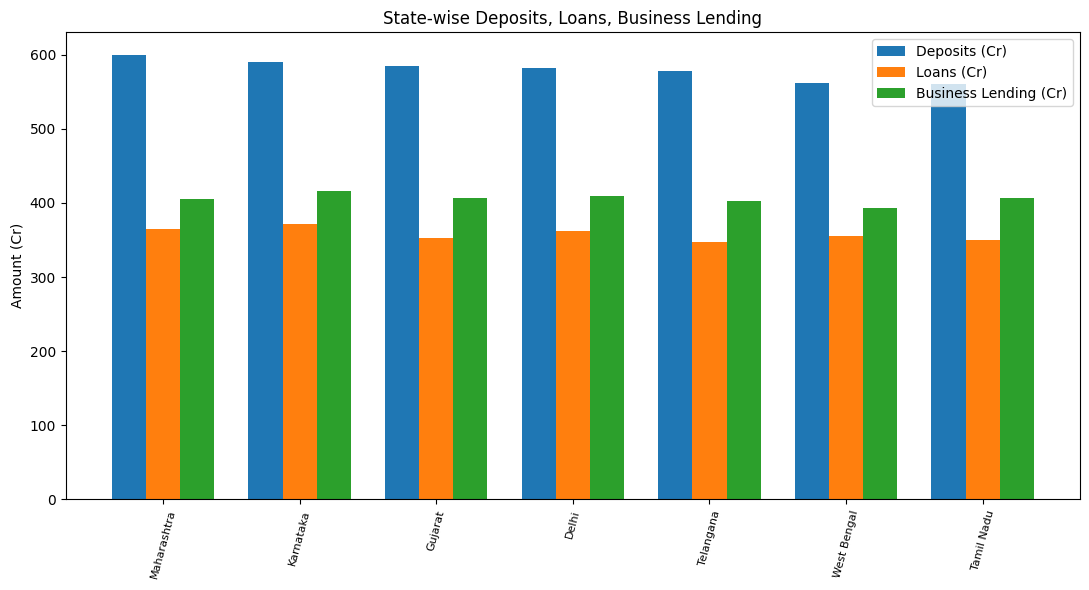

In [ ]:
state_metrics = df.groupby("State")[["Bank Deposits", "Bank Loans", "Business Lending"]].sum()
state_metrics = state_metrics.sort_values("Bank Deposits", ascending=False)

x = np.arange(len(state_metrics))
width = 0.25
plt.figure(figsize=(11, 6))
plt.bar(x - width, state_metrics["Bank Deposits"] / 1e7, width, label="Deposits (Cr)")
plt.bar(x, state_metrics["Bank Loans"] / 1e7, width, label="Loans (Cr)")
plt.bar(x + width, state_metrics["Business Lending"] / 1e7, width, label="Business Lending (Cr)")
plt.xticks(x, state_metrics.index, rotation=75, fontsize=8)
plt.ylabel("Amount (Cr)")
plt.title("State-wise Deposits, Loans, Business Lending")
plt.legend()
plt.tight_layout()
plt.savefig("chart8_state_metrics.png")
plt.show()

In [ ]:
total_deposits = df["Bank Deposits"].sum()
total_loans = df["Bank Loans"].sum()
total_business = df["Business Lending"].sum()
total_cc = df["Credit Card Balance"].sum()

print("Total Deposits (Cr):", round(total_deposits / 1e7, 1))
print("Total Loans (Cr):", round(total_loans / 1e7, 1))
print("Total Business Lending (Cr):", round(total_business / 1e7, 1))
print("Total CC Outstanding (Cr):", round(total_cc / 1e7, 1))

Total Deposits (Cr): 4058.3
Total Loans (Cr): 2504.3
Total Business Lending (Cr): 2841.2
Total CC Outstanding (Cr): 74.9


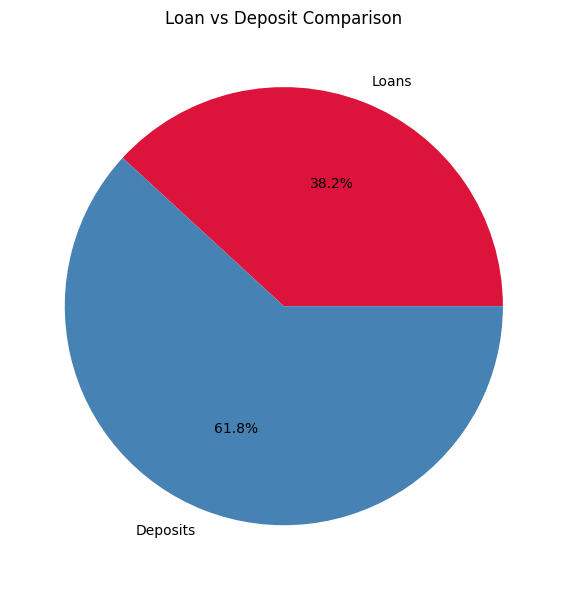

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie([total_loans, total_deposits], labels=["Loans", "Deposits"], autopct="%1.1f%%", colors=["crimson", "steelblue"])
plt.title("Loan vs Deposit Comparison")
plt.tight_layout()
plt.savefig("chart9_loan_vs_deposit.png")
plt.show()

## 6. Customer Profitability

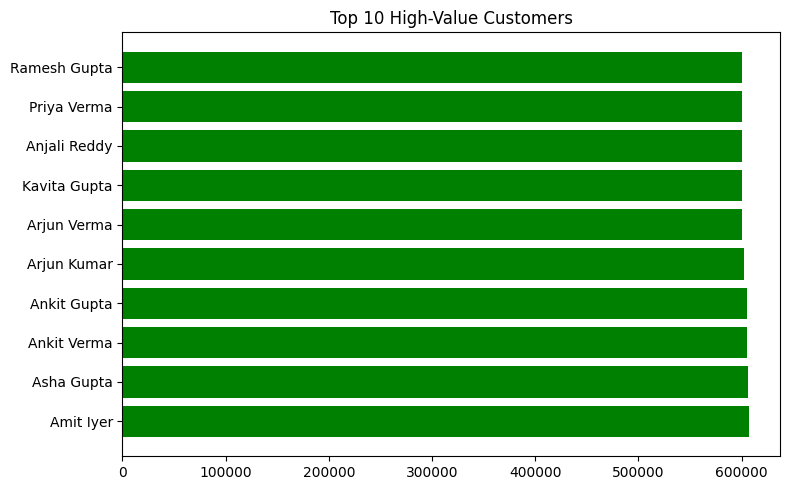

In [ ]:
df["Total Balance"] = df["Checking Accounts"] + df["Saving Accounts"] + df["Foreign Currency Account"]
df["Loan to Income Ratio"] = df["Bank Loans"] / df["Estimated Income"]
df["Profitability Score"] = df["Bank Deposits"] * 0.02 + df["Bank Loans"] * 0.09 - df["Credit Card Balance"] * 0.01

top10 = df.nlargest(10, "Profitability Score")
plt.figure(figsize=(8, 5))
plt.barh(top10["Name"], top10["Profitability Score"], color="green")
plt.title("Top 10 High-Value Customers")
plt.tight_layout()
plt.savefig("chart10_top10_customers.png")
plt.show()

## 7. Risk Exposure

In [ ]:
high_risk = df[df["Risk Weighting"] >= 4]
print("High risk customer count:", len(high_risk))
print("Total loan exposure (Cr):", round(df["Bank Loans"].sum() / 1e7, 1))

High risk customer count: 4000
Total loan exposure (Cr): 2504.3


## 8. Expansion Strategy

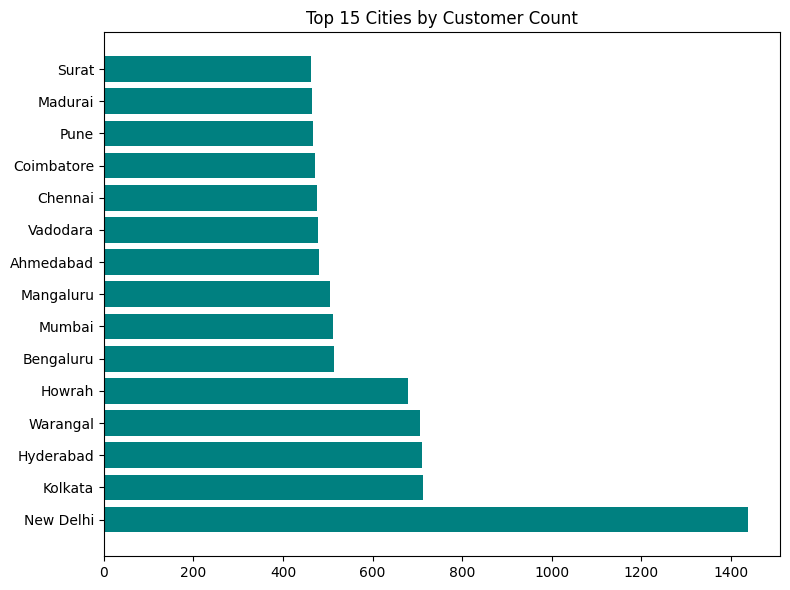

In [ ]:
city_metrics = df.groupby("City").agg(customers=("Client ID", "count"), avg_income=("Estimated Income", "mean"))
city_metrics = city_metrics.sort_values("customers", ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(city_metrics.index, city_metrics["customers"], color="teal")
plt.title("Top 15 Cities by Customer Count")
plt.tight_layout()
plt.savefig("chart11_top_cities.png")
plt.show()

## 9. Demographics

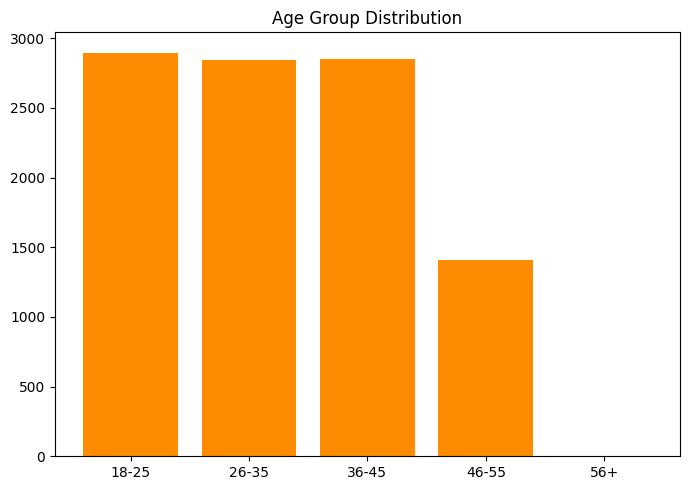

In [ ]:
bins = [17, 25, 35, 45, 55, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_group_count = df["Age Group"].value_counts().sort_index()
plt.figure(figsize=(7, 5))
plt.bar(age_group_count.index.astype(str), age_group_count.values, color="darkorange")
plt.title("Age Group Distribution")
plt.tight_layout()
plt.savefig("chart12_age_distribution.png")
plt.show()

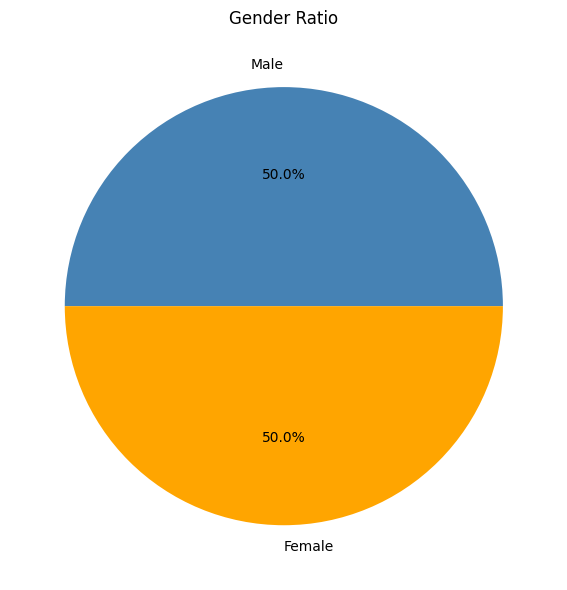

In [ ]:
gender_count = df["Gender"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_count.values, labels=gender_count.index, autopct="%1.1f%%", colors=["steelblue", "orange"])
plt.title("Gender Ratio")
plt.tight_layout()
plt.savefig("chart13_gender_ratio.png")
plt.show()

## 10. Executive Overview

In [ ]:
print("--- EXECUTIVE OVERVIEW ---")
print("Total Customers:", len(df))
print("Total Deposits (Cr):", round(total_deposits / 1e7, 1))
print("Total Loan Exposure (Cr):", round(total_loans / 1e7, 1))
print("High Risk Ratio:", round((df["Risk Weighting"] >= 4).mean() * 100, 1), "%")

--- EXECUTIVE OVERVIEW ---
Total Customers: 10000
Total Deposits (Cr): 4058.3
Total Loan Exposure (Cr): 2504.3
High Risk Ratio: 40.0 %


## 12. Gender-based Financial Behavior

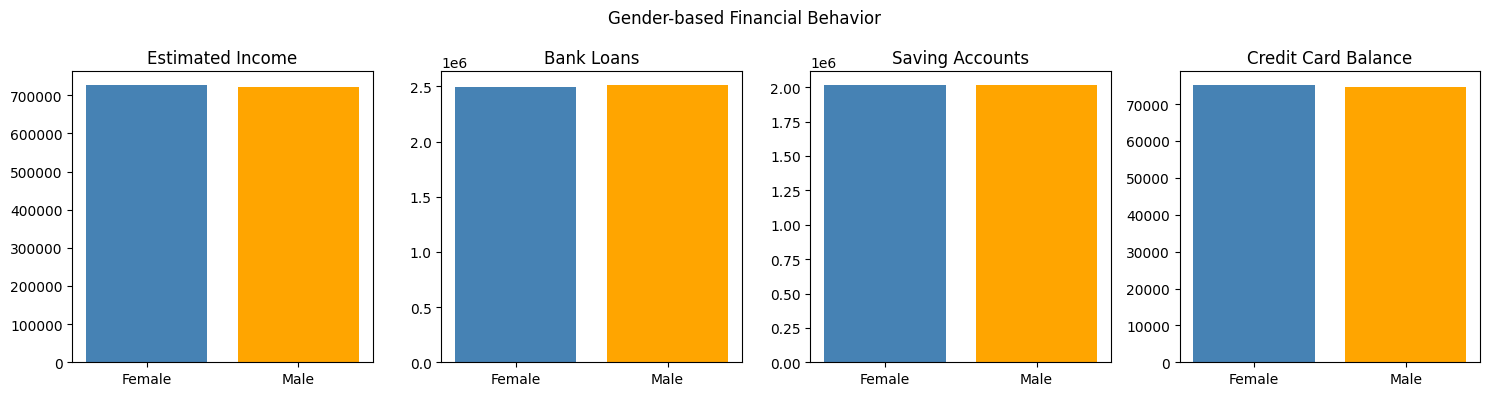

In [ ]:
gender_behavior = df.groupby("Gender")[["Estimated Income", "Bank Loans", "Saving Accounts", "Credit Card Balance"]].mean()

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
metrics = ["Estimated Income", "Bank Loans", "Saving Accounts", "Credit Card Balance"]
for ax, metric in zip(axes, metrics):
    ax.bar(gender_behavior.index, gender_behavior[metric], color=["steelblue", "orange"])
    ax.set_title(metric)
plt.suptitle("Gender-based Financial Behavior")
plt.tight_layout()
plt.savefig("chart14_gender_behavior.png")
plt.show()